# VGG19 Heart Sound Classification
## PASCAL Dataset — 4-Class VGG19 Transfer Learning Using Normalized Mel-Spectrogram Input
## Classes: Normal, Murmur, Extrasystole, Artifact


## GPU Setup

In [3]:
import os
import tensorflow as tf

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU Memory Growth Enabled for: {physical_devices}')
    except RuntimeError as e:
        print(f'GPU Error: {e}')
else:
    print('No GPU detected. Running on CPU.')


GPU Memory Growth Enabled for: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Foundation Set Up and Configuration

In [5]:
import os
import numpy as np
import librosa
import librosa.display
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
from cryptography.utils import CryptographyDeprecationWarning

warnings.filterwarnings('ignore', category=CryptographyDeprecationWarning)
np.random.seed(42)
print('Libraries imported successfully!')

BASE_PATH = r'C:\Users\emirh\Downloads\FYP2\Pascal'
FOLDERS = ['set_a', 'set_b']
SAMPLE_RATE = 16000
DURATION = 5
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

print(f'BASE_PATH : {BASE_PATH}')
print(f'FOLDERS   : {FOLDERS}')
print(f'SAMPLE_RATE : {SAMPLE_RATE}')
print(f'DURATION    : {DURATION}s')


Libraries imported successfully!
BASE_PATH : C:\Users\emirh\Downloads\FYP2\Pascal
FOLDERS   : ['set_a', 'set_b']
SAMPLE_RATE : 16000
DURATION    : 5s


## Data Augmentation Functions

In [7]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    """Generates the filter coefficients."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Applies the Bandpass Filter (25-400Hz)."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = signal.lfilter(b, a, data)
    return y

def fix_duration_segmentation(data):
    """
    Apply 5-Second Fixed Segmentation.
    - If shorter than 5s: Pad with zeros.
    - If longer than 5s: Truncate.
    """
    if len(data) > SAMPLES_PER_TRACK:
        return data[:SAMPLES_PER_TRACK]
    else:
        padding = SAMPLES_PER_TRACK - len(data)
        return np.pad(data, (0, padding), 'constant')

def z_score_normalize(data):
    """
    Applies Z-Score Normalization (Standardization).
    Result has Mean = 0, Std Dev = 1.
    """
    mean = np.mean(data)
    std = np.std(data)
    if std > 0:
        return (data - mean) / std
    else:
        return data

# AUGMENTATION FUNCTIONS
def add_noise_awgn(data):
    sigma = np.sqrt(np.mean(data ** 2))   # RMS of the signal
    noise = np.random.normal(0, sigma, len(data))
    return data + noise

def pitch_shift(data, sampling_rate):
    p = np.random.randint(1, 11)          # integer in [1, 10]
    direction = np.random.choice([-1, 1]) # up or down
    n_steps = direction * p
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

print('Preprocessing and augmentation functions defined.')


Preprocessing and augmentation functions defined.


## Feature Extraction (Mel-Spectrogram — 224×224)

> The MFCC extraction is replaced with a mel-spectrogram.
> The mel-spectrogram is computed with `n_mels=224`, converted to dB scale,
> then padded/truncated to 224 time frames and transposed to `(224, 224)`
> as the sequential input for the CNN.
> All other preprocessing (bandpass filter, segmentation, z-score normalisation) is unchanged.


In [9]:
# Mel-spectrogram configuration
N_MELS        = 224
MEL_TIME_STEPS = 224
N_FFT         = 2048
HOP_LENGTH    = 512

def extract_features(audio_data, sample_rate):
    
    mel_spec = librosa.feature.melspectrogram(
        y=audio_data,
        sr=sample_rate,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Convert power spectrogram to dB scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Clip dB range to keep values between -80 and 0
    mel_spec_db = np.clip(mel_spec_db, -80, 0)

    # Pad or truncate along the time axis
    if mel_spec_db.shape[1] < MEL_TIME_STEPS:
        pad_width = MEL_TIME_STEPS - mel_spec_db.shape[1]
        mel_spec_db = np.pad(
            mel_spec_db,
            pad_width=((0, 0), (0, pad_width)),
            mode='constant',
            constant_values=-80
        )
    else:
        mel_spec_db = mel_spec_db[:, :MEL_TIME_STEPS]

    # Transpose to (time_steps, mel_features) = (224, 224)
    mel_spec_db = mel_spec_db.T

    # Normalize from [-80, 0] to [0, 1]
    mel_spec_norm = (mel_spec_db + 80) / 80

    return mel_spec_norm.astype(np.float32)

print('Feature extraction function defined (Normalized Mel-Spectrogram).')
print(f'Output shape per sample: ({MEL_TIME_STEPS}, {N_MELS})')
print('Mel-spectrogram values are normalized to range [0, 1].')


Feature extraction function defined (Normalized Mel-Spectrogram).
Output shape per sample: (224, 224)
Mel-spectrogram values are normalized to range [0, 1].


## Data Preparation (Mel-Spectrogram — Noise Injection + Pitch Shift Augmentation on Training Set)


In [11]:
from tensorflow.keras.utils import to_categorical
from collections import Counter


file_paths = []
labels = []

print('Scanning folders...')
for folder in FOLDERS:
    folder_path = os.path.join(BASE_PATH, folder)
    if not os.path.exists(folder_path):
        continue

    for filename in os.listdir(folder_path):
        filename_lower = filename.lower()

        if not filename_lower.endswith('.wav') or 'unlabel' in filename_lower:
            continue

        # Exclude noisy files and ExtraHLS class for 4-class classification
        if 'noisy' in filename_lower or 'extrahls' in filename_lower:
            continue

        file_path = os.path.join(folder_path, filename)

        # Label Logic for 4 classes
        label = None
        if 'normal' in filename_lower:
            label = 0
        elif 'murmur' in filename_lower:
            label = 1
        elif 'extrastole' in filename_lower or 'extrasystole' in filename_lower:
            label = 2
        elif 'artifact' in filename_lower:
            label = 3

        if label is not None:
            file_paths.append(file_path)
            labels.append(label)

# Class names for 4-class PASCAL classification
class_names = {
    0: 'Normal',
    1: 'Murmur',
    2: 'Extrasystole',
    3: 'Artifact'
}

print(f'\nTotal valid files gathered: {len(labels)}')
distribution = Counter(labels)
print('-' * 30)
print('CLASS DISTRIBUTION (Before Split):')
for label_int in sorted(distribution.keys()):
    print(f' - {class_names[label_int]}: {distribution[label_int]} files')
print('-' * 30 + '\n')

# ============================================================
# 2. STRATIFIED SPLIT: 70 / 10 / 20
# ============================================================
X_train_val_paths, X_test_paths, y_train_val_labels, y_test_labels = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

X_train_paths, X_val_paths, y_train_labels, y_val_labels = train_test_split(
    X_train_val_paths, y_train_val_labels, test_size=0.125, stratify=y_train_val_labels, random_state=42
)

print(f'File Counts -> Train: {len(X_train_paths)}, Val: {len(X_val_paths)}, Test: {len(X_test_paths)}')

max_original_class_count = max(distribution.values()) if len(distribution) > 0 else 0
TARGET_COUNTS = {
    0: max_original_class_count,  # Normal
    1: max_original_class_count,  # Murmur
    2: max_original_class_count,  # Extrasystole
    3: max_original_class_count   # Artifact
}

print('TARGET_COUNTS for training augmentation:')
for label_int in sorted(TARGET_COUNTS.keys()):
    print(f' - {class_names[label_int]:<12}: {TARGET_COUNTS[label_int]}')


Scanning folders...

Total valid files gathered: 417
------------------------------
CLASS DISTRIBUTION (Before Split):
 - Normal: 231 files
 - Murmur: 100 files
 - Extrasystole: 46 files
 - Artifact: 40 files
------------------------------

File Counts -> Train: 291, Val: 42, Test: 84
TARGET_COUNTS for training augmentation:
 - Normal      : 231
 - Murmur      : 231
 - Extrasystole: 231
 - Artifact    : 231


### Processing Function

> `process_data_with_augmentation` is identical to the MFCC version.
> The only difference is that `extract_features` now returns a mel-spectrogram
> array of shape `(224, 224)` instead of an MFCC array of shape `(24, 13)`.
> Augmentation (AWGN noise + pitch shift, alternating) is unchanged.


In [13]:
def process_data_with_augmentation(X_paths, y_labels, augment=False):
    X_mels = []
    y_final = []

    # Store original preprocessed audio for augmentation
    audio_by_class = {0: [], 1: [], 2: [], 3: []}

    print(f'   Processing {len(X_paths)} files (Augment={augment})...')

    # ====================================================
    # STEP 1: Process original files
    # ====================================================
    for i, fpath in enumerate(X_paths):
        try:
            y, sr = librosa.load(fpath, sr=SAMPLE_RATE, duration=DURATION)

            y = butter_bandpass_filter(y, 25, 400, sr)
            y = fix_duration_segmentation(y)
            y = z_score_normalize(y)

            current_label = y_labels[i]

            mel = extract_features(y, sr)

            X_mels.append(mel)
            y_final.append(current_label)

            audio_by_class[current_label].append((y, sr))

        except Exception as e:
            print(f'[SKIPPED ORIGINAL] {fpath} -> {e}')

    if augment:
        print('\n   Applying combined augmentation: AWGN noise injection + pitch shifting...')

        current_distribution = Counter(y_final)

        for label in sorted(TARGET_COUNTS.keys()):
            current_count = current_distribution[label]
            target_count = TARGET_COUNTS[label]
            needed = target_count - current_count

            print(
                f'   {class_names[label]:<12}: '
                f'current={current_count}, target={target_count}, need={needed}'
            )

            if needed <= 0:
                continue

            if len(audio_by_class[label]) == 0:
                print(f'   No audio available for {class_names[label]}. Skipping.')
                continue

            added = 0
            audio_index = 0

            while added < needed:
                y_original, sr = audio_by_class[label][audio_index % len(audio_by_class[label])]

                try:
                    # Alternate augmentation type to use both methods
                    if added % 2 == 0:
                        y_aug = add_noise_awgn(y_original)
                    else:
                        y_aug = pitch_shift(y_original, sr)

                    mel_aug = extract_features(y_aug, sr)

                    X_mels.append(mel_aug)
                    y_final.append(label)

                    added += 1
                    audio_index += 1

                except Exception as e:
                    print(f'   [SKIPPED AUGMENTATION] {class_names[label]} -> {e}')
                    audio_index += 1

    return np.array(X_mels), np.array(y_final)


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Combined AWGN noise injection and pitch-shift augmentation applied to training split only
print('Processing Training Data (AWGN Noise Injection + Pitch Shift Augmentation)...')
X_train_mel, y_train_indices = process_data_with_augmentation(
    X_train_paths, y_train_labels, augment=True
)

# Print post-augmentation distribution
aug_distribution = Counter(y_train_indices)
print('\n' + '=' * 35)
print('TRAINING DATA AFTER AWGN NOISE INJECTION + PITCH SHIFT AUGMENTATION (Mel-Spectrogram):')
for label_int in sorted(aug_distribution.keys()):
    print(f' - {class_names[label_int]}: {aug_distribution[label_int]} files')
print('=' * 35 + '\n')

print('\nProcessing Validation Data (No Augmentation)...')
X_val_mel, y_val_indices = process_data_with_augmentation(
    X_val_paths, y_val_labels, augment=False
)

print('\nProcessing Test Data (No Augmentation)...')
X_test_mel, y_test_indices = process_data_with_augmentation(
    X_test_paths, y_test_labels, augment=False
)

# Float32 conversion
X_train_mel = X_train_mel.astype('float32')
X_val_mel   = X_val_mel.astype('float32')
X_test_mel  = X_test_mel.astype('float32')

# VGG19 requires 3-channel input of shape (224, 224, 3).
# Step 1: Add channel dimension — (N, 224, 224) → (N, 224, 224, 1)
if X_train_mel.ndim == 3:
    X_train_mel = np.expand_dims(X_train_mel, axis=-1)
if X_val_mel.ndim == 3:
    X_val_mel = np.expand_dims(X_val_mel, axis=-1)
if X_test_mel.ndim == 3:
    X_test_mel = np.expand_dims(X_test_mel, axis=-1)

# Step 2: Replicate single channel to 3 channels — (N, 224, 224, 1) → (N, 224, 224, 3)
X_train_mel = np.repeat(X_train_mel, 3, axis=-1)
X_val_mel   = np.repeat(X_val_mel,   3, axis=-1)
X_test_mel  = np.repeat(X_test_mel,  3, axis=-1)

# One-hot encoding (4 classes)
y_train = to_categorical(y_train_indices, num_classes=4)
y_val   = to_categorical(y_val_indices,   num_classes=4)
y_test  = to_categorical(y_test_indices,  num_classes=4)

y_train = y_train.astype('float32')
y_val   = y_val.astype('float32')
y_test  = y_test.astype('float32')

# Class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights = dict(enumerate(class_weights_array))

print('--- FINAL ARRAYS READY ---')
print(f'VGG19 Input Shape (Train) : {X_train_mel.shape}')  # (N, 224, 224, 3)
print(f'VGG19 Input Shape (Val)   : {X_val_mel.shape}')
print(f'VGG19 Input Shape (Test)  : {X_test_mel.shape}')
print(f'Label Shape (Train)     : {y_train.shape}')

print('\nClass Weights:')
for k, v in class_weights.items():
    print(f'  [{k}] {class_names[k]:<12}: {v:.4f}')


Processing Training Data (AWGN Noise Injection + Pitch Shift Augmentation)...
   Processing 291 files (Augment=True)...

   Applying combined augmentation: AWGN noise injection + pitch shifting...
   Normal      : current=161, target=231, need=70
   Murmur      : current=70, target=231, need=161
   Extrasystole: current=32, target=231, need=199
   Artifact    : current=28, target=231, need=203

TRAINING DATA AFTER AWGN NOISE INJECTION + PITCH SHIFT AUGMENTATION (Mel-Spectrogram):
 - Normal: 231 files
 - Murmur: 231 files
 - Extrasystole: 231 files
 - Artifact: 231 files


Processing Validation Data (No Augmentation)...
   Processing 42 files (Augment=False)...

Processing Test Data (No Augmentation)...
   Processing 84 files (Augment=False)...
--- FINAL ARRAYS READY ---
VGG19 Input Shape (Train) : (924, 224, 224, 3)
VGG19 Input Shape (Val)   : (42, 224, 224, 3)
VGG19 Input Shape (Test)  : (84, 224, 224, 3)
Label Shape (Train)     : (924, 4)

Class Weights:
  [0] Normal      : 1.0000
  

## Model Training — VGG19 Transfer Learning 

> **Architecture:**
> ```
> VGG19(imagenet, include_top=False, input=(224,224,3))
>   → Flatten
>   → Dense(1024, ReLU)
>   → Dense(4, Softmax)   ← 4-class PASCAL output
> ```


In [16]:
import gc
import math
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Clear memory
K.clear_session()
gc.collect()
print('Memory cleared.')

# Memory-safe generator (identical to CNN notebook)
class NumpyDataGenerator(Sequence):
    def __init__(self, X, y, batch_size=4, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.X) / self.batch_size)

    def __getitem__(self, index):
        batch_indices = self.indices[
            index * self.batch_size : (index + 1) * self.batch_size
        ]
        X_batch = self.X[batch_indices].astype('float32')
        y_batch = self.y[batch_indices].astype('float32')
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


BATCH_SIZE = 4

train_gen = NumpyDataGenerator(X_train_mel, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = NumpyDataGenerator(X_val_mel,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print('Memory-safe generators created.')


# Step 1: Load pre-trained VGG19 base (ImageNet weights, no top layers)
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # Freeze VGG19 weights

# Step 2: Build the full model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Step 3: Flatten (as specified in the paper)
x = Flatten()(x)

# Step 4: Dense(1024, ReLU) — as specified in the paper
x = Dense(1024, activation='relu')(x)

# Step 5: Classification layer — softmax for 4-class PASCAL
outputs = Dense(4, activation='softmax')(x)

final_model = Model(inputs, outputs, name='VGG19_Pascal_PandeyArch_4Class')

# Compile 
final_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

final_model.summary()

# Callbacks 
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

print('Training VGG19 model...')

history = final_model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[early_stopper, reduce_lr],
    class_weight=class_weights
)


Memory cleared.
Memory-safe generators created.
Model: "VGG19_Pascal_PandeyArch_4Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 1024)              25691136  
                                                                 
 dense_1 (Dense)             (None, 4)                 4100      
                                                                 
Total params: 45,719,620
Trainable params: 25,695,236
Non-trainable params: 20,024,384
_________________________________

In [17]:
import gc
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

model_path = 'vgg19_melspec_pascal_4class.h5'

print('Current directory:', os.getcwd())

final_model.save(model_path)
print('Model saved successfully!')

K.clear_session()
gc.collect()
print('Memory cleared after training.')



Current directory: C:\Users\emirh\Downloads\FYP2\Models_PASCAL\MelSpectogram_As_Input\VGG19\Models_AftrChanges\Norm\For Compare
Model saved successfully!
Memory cleared after training.


## Training Curves

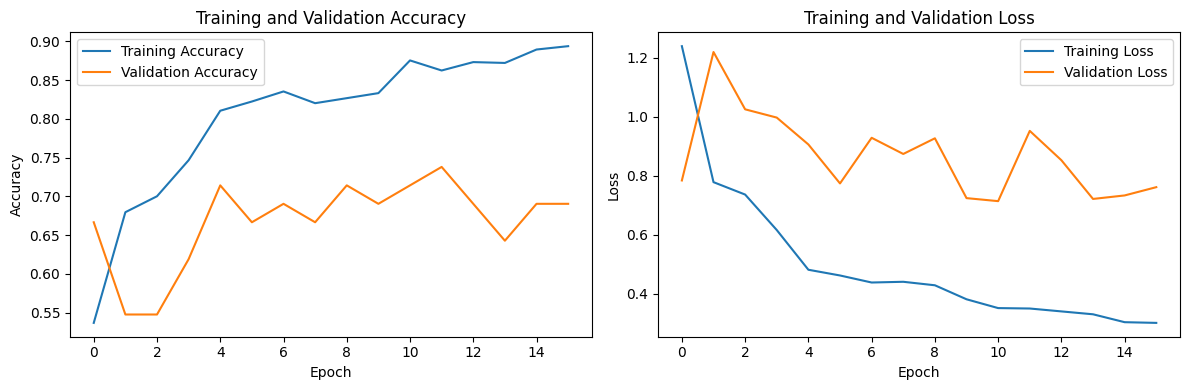

In [19]:
if 'history' in locals():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No history found. Please train the model first.')


## Classification Output

> Evaluation function identical to `DeepLearningModel_VGG19_MFCC_Test1.ipynb`.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Class labels for 4-class PASCAL classification
classes = ['Normal', 'Murmur', 'ExtraSys', 'Artifact']

def evaluate_and_plot_manual(model, X, y, set_name, batch_size=1):
    print(f"\n{'='*20} {set_name.upper()} RESULTS {'='*20}")

    y_true_all = []
    y_pred_all = []

    total_samples = len(X)

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)

        X_batch = X[start:end].astype('float32')
        y_batch = y[start:end]

        pred_batch = model.predict(X_batch, verbose=0)

        y_pred_all.extend(np.argmax(pred_batch, axis=1))
        y_true_all.extend(np.argmax(y_batch, axis=1))

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    print(f'{set_name} Accuracy: {acc * 100:.2f}%')

    cm = confusion_matrix(y_true_all, y_pred_all)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f'Confusion Matrix ({set_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=classes,
        labels=[0, 1, 2, 3],
        zero_division=0
    ))



==================== TRAINING SET RESULTS ====================
Training Set Accuracy: 84.42%


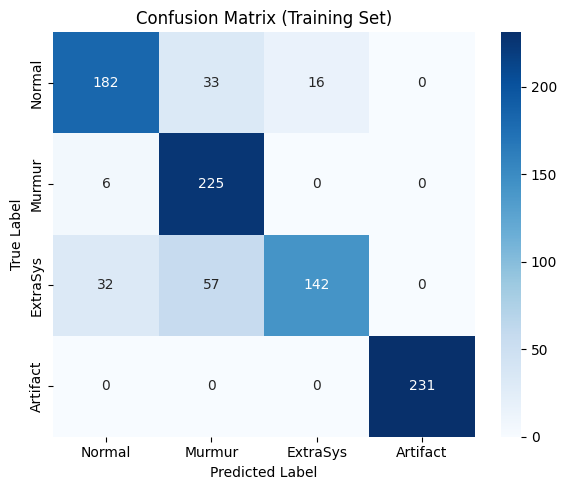

              precision    recall  f1-score   support

      Normal       0.83      0.79      0.81       231
      Murmur       0.71      0.97      0.82       231
    ExtraSys       0.90      0.61      0.73       231
    Artifact       1.00      1.00      1.00       231

    accuracy                           0.84       924
   macro avg       0.86      0.84      0.84       924
weighted avg       0.86      0.84      0.84       924



In [22]:
evaluate_and_plot_manual(final_model, X_train_mel, y_train, 'Training Set', batch_size=1)



==================== VALIDATION SET RESULTS ====================
Validation Set Accuracy: 71.43%


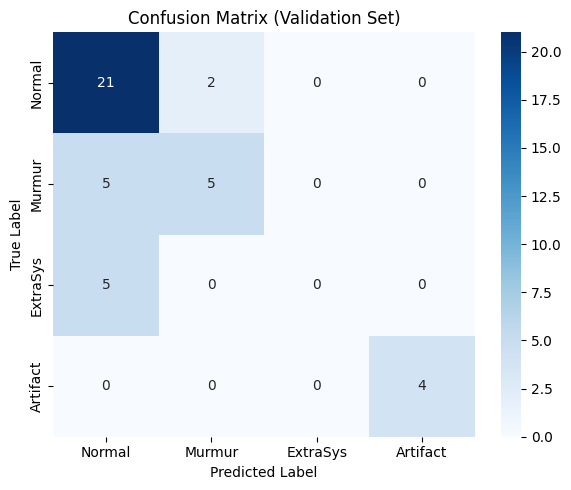

              precision    recall  f1-score   support

      Normal       0.68      0.91      0.78        23
      Murmur       0.71      0.50      0.59        10
    ExtraSys       0.00      0.00      0.00         5
    Artifact       1.00      1.00      1.00         4

    accuracy                           0.71        42
   macro avg       0.60      0.60      0.59        42
weighted avg       0.64      0.71      0.66        42



In [23]:
evaluate_and_plot_manual(final_model, X_val_mel,   y_val,   'Validation Set', batch_size=1)



==================== TEST SET RESULTS ====================
Test Set Accuracy: 75.00%


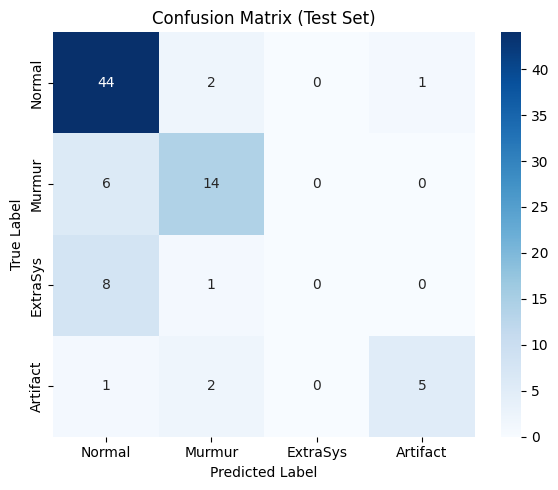

              precision    recall  f1-score   support

      Normal       0.75      0.94      0.83        47
      Murmur       0.74      0.70      0.72        20
    ExtraSys       0.00      0.00      0.00         9
    Artifact       0.83      0.62      0.71         8

    accuracy                           0.75        84
   macro avg       0.58      0.57      0.57        84
weighted avg       0.67      0.75      0.70        84



In [24]:
evaluate_and_plot_manual(final_model, X_test_mel,  y_test,  'Test Set', batch_size=1)
